# Notebook 3 — Modeling & Evaluation

In this notebook, we build and evaluate machine learning models
to predict customer churn.

Objectives:
- Prepare train/test datasets
- Train baseline and advanced models
- Evaluate performance using appropriate metrics
- Interpret model results

## Import Libraries

We import the necessary machine learning and evaluation libraries.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
np.random.seed(42)

## Load Processed Dataset

We load the cleaned and encoded dataset from the previous notebooks.

In [2]:
df = pd.read_csv("C:/Users/hlias/Desktop/telco-churn-prediction/data/processed/telco_churn_clean.csv")

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


## Define Features and Target Variable

- Target: Churn
- Features: All remaining columns

In [3]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X.shape, y.shape

((7032, 30), (7032,))

## Train-Test Split

We split the dataset into training and test sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

X_train.shape, X_test.shape

((5274, 30), (1758, 30))

## Feature Scaling

Logistic Regression benefits from feature scaling.
We apply standardization.

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

We train a baseline logistic regression model.

In [6]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Logistic Regression Evaluation

In [7]:
y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_proba_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8077360637087599
ROC AUC: 0.8400066678056118
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1291
           1       0.66      0.58      0.62       467

    accuracy                           0.81      1758
   macro avg       0.76      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758



## Random Forest Model

We train a Random Forest classifier for improved performance.

In [8]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Random Forest Evaluation

In [9]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7906712172923777
ROC AUC: 0.819004738786227
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1291
           1       0.64      0.48      0.55       467

    accuracy                           0.79      1758
   macro avg       0.73      0.69      0.71      1758
weighted avg       0.78      0.79      0.78      1758



## ROC Curve Comparison

We compare the ROC curves of both models.

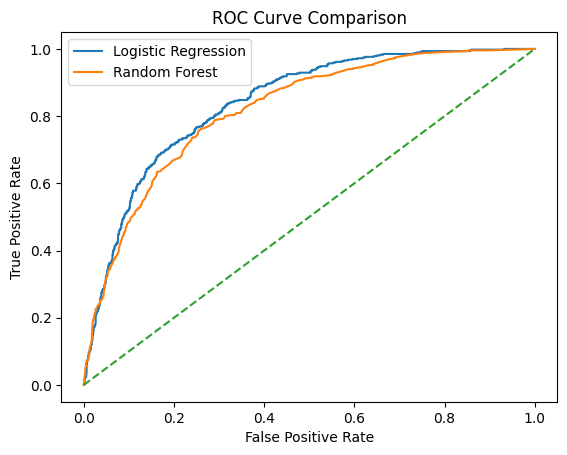

In [10]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure()
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("../outputs/figures/roc_curve.png", bbox_inches="tight")
plt.show()

## Feature Importance

We analyze the most important features driving churn predictions.

In [11]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

TotalCharges                      0.176057
tenure                            0.163910
MonthlyCharges                    0.150560
Contract_Two year                 0.059362
InternetService_Fiber optic       0.042265
PaymentMethod_Electronic check    0.034863
OnlineSecurity_Yes                0.028421
Contract_One year                 0.027840
gender_Male                       0.026044
TechSupport_Yes                   0.024515
dtype: float64

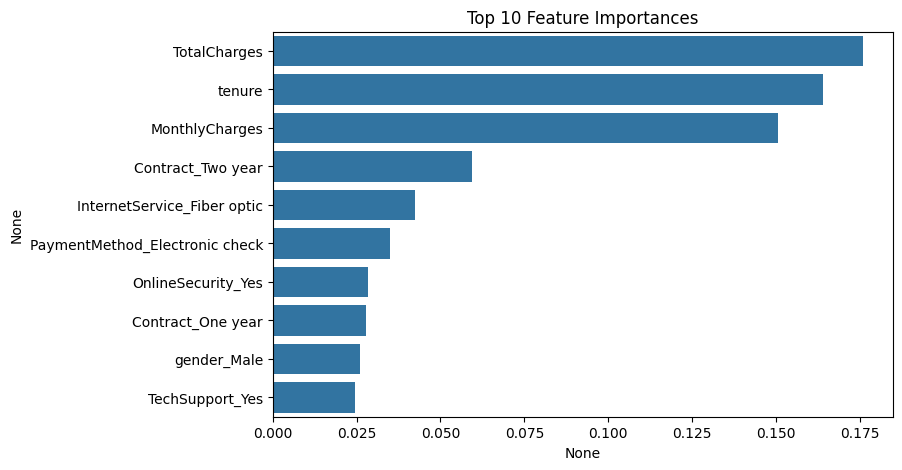

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance.head(10), y=feature_importance.head(10).index)
plt.title("Top 10 Feature Importances")
plt.savefig("../outputs/figures/feature_importance.png", bbox_inches="tight")
plt.show()

## Model Comparison Summary

- Logistic Regression provides interpretability and baseline performance
- Random Forest achieves higher ROC AUC
- Tenure, Contract Type, Monthly Charges are key churn drivers

## Business Insights

- Customers on month-to-month contracts are more likely to churn
- Short-tenure customers represent the highest churn risk
- Pricing and contract structure are strong churn levers